## Pattern Recognition Assignment 2

# Wine Quality Classification Using SVM and XGBoost
# Name : Marah Amjad Qandeel
Num Student: 2320226461


In [2]:
import numpy as np
import pandas as pd
# Visualization



import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

# Models
from sklearn.svm import SVC
from xgboost import XGBClassifier


red_wine = pd.read_csv('/content/drive/MyDrive/winequality-red.csv',sep=';')
white_wine = pd.read_csv('/content/drive/MyDrive/winequality-white.csv',sep=';')


In [3]:
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Combine Red & White Wine

In [4]:
red_wine['wine_type']= 0     #red/0
white_wine['wine_type'] = 1   #white/1


wine = pd.concat([red_wine,white_wine],axis=0)
wine.reset_index(drop=True,inplace=True)

wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


Eplor dataset

In [5]:
wine.info()

wine.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.753886
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,1.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


Create Classification Label

In [6]:
wine['quality_label']= wine['quality'].apply(lambda x:1 if x>=6 else 0)

wine['quality_label'].value_counts()

,count
quality_label,
1,4113
0,2384


###  Split Features and Target

In [7]:
x =wine.drop(['quality','quality_label'],axis=1)
# target
y = wine['quality_label']

y.head()

x_test,x_train ,y_test,y_train = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
scaler = StandardScaler()

x_train_scaled =scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Hard Margin SVM


In [9]:
hard_svm =SVC(
    kernel='linear',
    C = 100,
     probability=True

)
hard_svm.fit(x_train_scaled,y_train)
y_pred_hard =hard_svm.predict(x_test_scaled)
y_prob_hard = hard_svm.predict_proba(x_test_scaled)[:,1]

Model Evaluation

In [10]:
 accuracy_hard = accuracy_score(y_test, y_pred_hard)
 f1_hard = f1_score(y_test, y_pred_hard)

 roc_hard = roc_auc_score(y_test, y_pred_hard)
 accuracy_hard,f1_hard,roc_hard

(0.7358091206465268, 0.7972234529611579, np.float64(0.7051482858704852))

** Soft Margin SVM**

In [11]:
soft_svm = SVC(
    kernel='linear',
    C=1.0,
    probability=True
)

soft_svm.fit(x_train_scaled,y_train)
y_pred_soft =soft_svm.predict(x_test_scaled)
y_prob_soft= soft_svm.predict_proba(x_test_scaled)[:,1]

**XGBoost Classifier**

In [12]:
xgb =  XGBClassifier(
    n_estimators=100,
    learning_rate =0.1,
    max_depth = 3,
    random_state =42,


)
# Train the model

xgb.fit(x_train,y_train)

## Predictions

y_pred_xgb =xgb.predict(x_test)
y_prob_xgb = xgb.predict_proba(x_test)[:, 1]


accuracy_xgb = accuracy_score(y_test,y_pred_xgb)
f1_xgb = f1_score(y_test,y_pred_xgb)

roc_xgb = roc_auc_score(y_test, y_prob_xgb)

accuracy_xgb,f1_xgb,roc_xgb

(0.7625553203771407, 0.8170225385527876, np.float64(0.8203089561254887))

**ROC Curve Comparison**

Hard سيكون متقطع --

Soft سيكون منقط :

XGBoost خط عادي

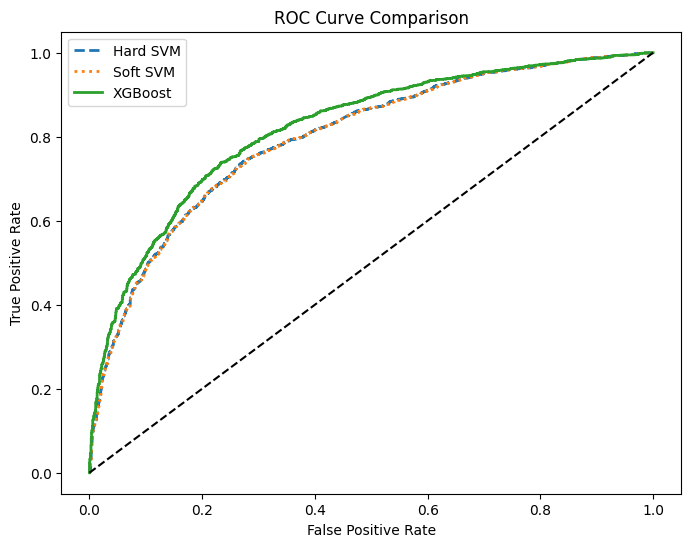

In [21]:
# ROC Hard SVM
fpr_hard, tpr_hard, _ = roc_curve(y_test, y_prob_hard)

# ROC Soft SVM
fpr_soft, tpr_soft, _ = roc_curve(y_test, y_prob_soft)

# ROC XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_hard, tpr_hard, linestyle='--', linewidth=2, label='Hard SVM')
plt.plot(fpr_soft, tpr_soft, linestyle=':', linewidth=2, label='Soft SVM')
plt.plot(fpr_xgb, tpr_xgb, linewidth=2, label='XGBoost')
# Random classifier line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()